<a href="https://colab.research.google.com/github/Sobhagyaverma/Smart-Plant-Care-System/blob/main/FINALCODE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q kaggle

import os, zipfile, shutil, joblib
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.optimizers import Adam

from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("TF Version:", tf.__version__)

TF Version: 2.19.0


In [ ]:
def setup_kaggle():
    os.makedirs('/root/.kaggle', exist_ok=True)
    shutil.copy('kaggle.json', '/root/.kaggle/kaggle.json')
    os.chmod('/root/.kaggle/kaggle.json', 0o600)

    os.system("kaggle datasets download -d vipoooool/new-plant-diseases-dataset")
    with zipfile.ZipFile("new-plant-diseases-dataset.zip", "r") as z:
        z.extractall(".")

setup_kaggle()


[INFO] Setting up Kaggle API...
[INFO] Downloading dataset: New Plant Diseases Dataset (Augmented)...
[INFO] Unzipping dataset...
[SUCCESS] Dataset ready.
Dataset setup complete.


In [ ]:
# ==========================================
# 2. CONFIGURATION
# ==========================================
# Adjust paths based on where the dataset extracted
# Often it extracts into a folder with the same name, or sometimes directly
BASE_DIR = 'New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)'
TRAIN_DIR = os.path.join(BASE_DIR, 'train')
VALID_DIR = os.path.join(BASE_DIR, 'valid')

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
RANDOM_STATE = 42

# Output files
CNN_MODEL_PATH = 'cnn_baseline.h5'
SVM_MODEL_PATH = 'svm_classifier.pkl'
SCALER_PATH = 'feature_scaler.pkl'

In [ ]:
BASE_DIR = "New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)"
TRAIN_DIR = os.path.join(BASE_DIR, "train")
VAL_DIR   = os.path.join(BASE_DIR, "valid")

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

CNN_MODEL_PATH = "cnn_mobilenetv2.keras"
SVM_MODEL_PATH = "svm_linear.pkl"
SCALER_PATH = "scaler.pkl"

In [ ]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)

val_gen = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

NUM_CLASSES = train_gen.num_classes
print("Classes:", NUM_CLASSES)

Found 70295 images belonging to 38 classes.
Found 17572 images belonging to 38 classes.
Classes: 38


In [ ]:
base_model = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False  # VERY IMPORTANT

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu", name="feature_layer")(x)
x = Dropout(0.5)(x)
outputs = Dense(NUM_CLASSES, activation="softmax")(x)

cnn_model = Model(inputs=base_model.input, outputs=outputs)

cnn_model.compile(
    optimizer=Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_model.summary()

history = cnn_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=5,
    verbose=1
)

cnn_model.save(CNN_MODEL_PATH)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,595,686 (9.90 MB)

 Trainable params: 337,702 (1.29 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 982s 438ms/step - accuracy: 0.6717 - loss: 1.1412 - val_accuracy: 0.9129 - val_loss: 0.2666
Epoch 2/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 930s 423ms/step - accuracy: 0.8692 - loss: 0.4056 - val_accuracy: 0.9210 - val_loss: 0.2391
Epoch 3/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 927s 422ms/step - accuracy: 0.8864 - loss: 0.3433 - val_accuracy: 0.9338 - val_loss: 0.2007
Epoch 4/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 918s 418ms/step - accuracy: 0.8954 - loss: 0.3201 - val_accuracy: 0.9311 - val_loss: 0.2049
Epoch 5/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 930s 423ms/step - accuracy: 0.9008 - loss: 0.3033 - val_accuracy: 0.9347 - val_loss: 0.1947


In [ ]:
feature_extractor = Model(
    inputs=cnn_model.input,
    outputs=cnn_model.get_layer("feature_layer").output
)

extract_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_ext = extract_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, shuffle=False
)

val_ext = extract_datagen.flow_from_directory(
    VAL_DIR, target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, shuffle=False
)

X_train = feature_extractor.predict(train_ext, verbose=1)
y_train = train_ext.classes

X_val = feature_extractor.predict(val_ext, verbose=1)
y_val = val_ext.classes

Found 70295 images belonging to 38 classes.
Found 17572 images belonging to 38 classes.
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 144s 63ms/step
550/550 ━━━━━━━━━━━━━━━━━━━━ 34s 62ms/step


In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

joblib.dump(scaler, SCALER_PATH)

['scaler.pkl']

In [ ]:
svm = LinearSVC(C=1.0, max_iter=5000)
svm.fit(X_train, y_train)

joblib.dump(svm, SVM_MODEL_PATH)

['svm_linear.pkl']

In [ ]:
y_pred = svm.predict(X_val)

acc = accuracy_score(y_val, y_pred)
print("CNN + SVM Accuracy:", acc)

print(classification_report(y_val, y_pred))

CNN + SVM Accuracy: 0.9568062827225131
              precision    recall  f1-score   support

           0       0.96      0.94      0.95       504
           1       0.97      0.99      0.98       497
           2       0.97      0.99      0.98       440
           3       0.98      0.99      0.99       502
           4       0.99      0.99      0.99       454
           5       0.98      0.99      0.99       421
           6       1.00      0.99      0.99       456
           7       0.94      0.88      0.91       410
           8       0.99      0.99      0.99       477
           9       0.90      0.95      0.92       477
          10       1.00      1.00      1.00       465
          11       0.97      0.97      0.97       472
          12       0.97      0.97      0.97       480
          13       1.00      1.00      1.00       430
          14       1.00      1.00      1.00       423
          15       0.99      1.00      0.99       503
          16       0.98      0.97      0.9

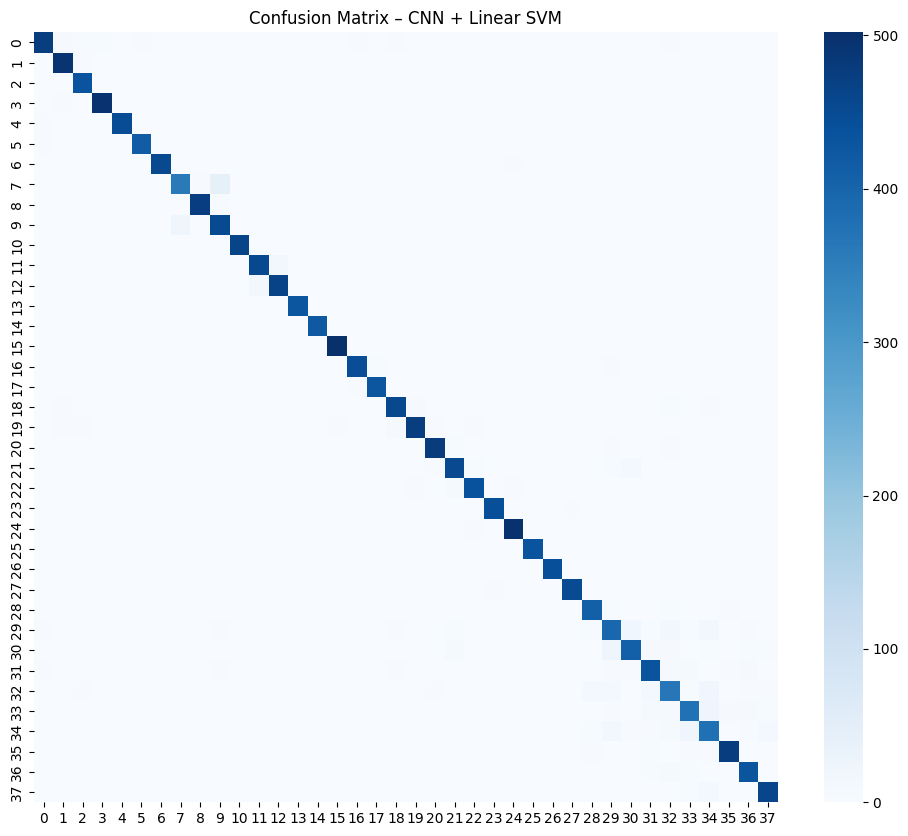

In [ ]:
cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(12,10))
sns.heatmap(cm, cmap="Blues", annot=False)
plt.title("Confusion Matrix – CNN + Linear SVM")
plt.show()

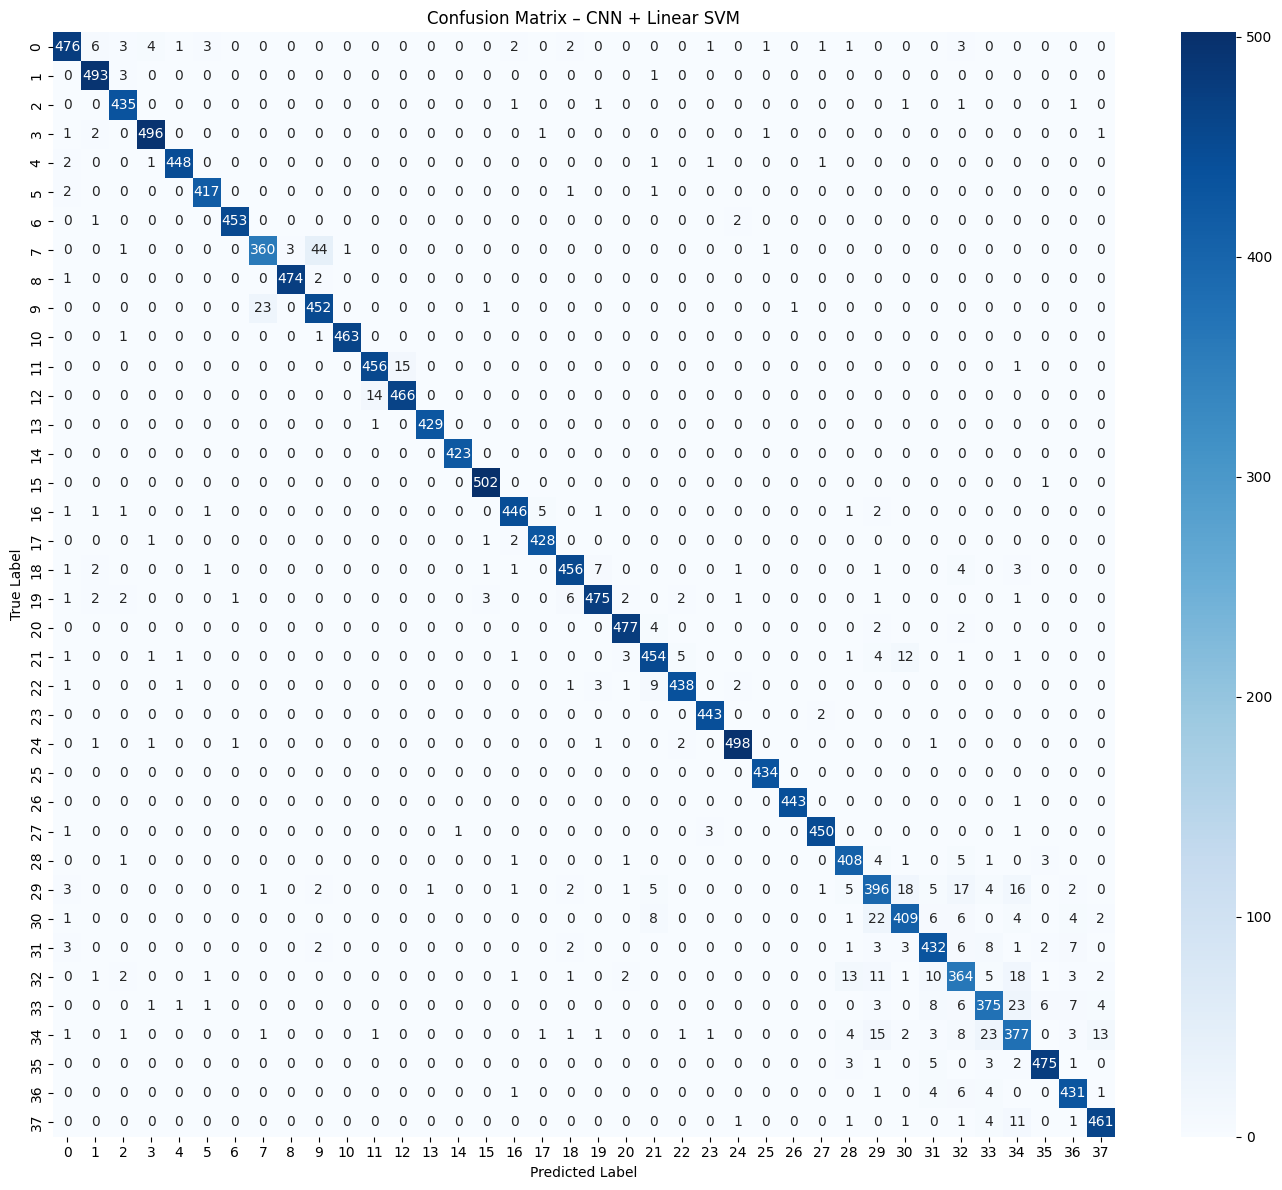

In [ ]:
cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(14, 12))
sns.heatmap(
    cm,
    cmap="Blues",
    annot=True,        # 🔥 THIS shows values
    fmt="d",           # integer format
    xticklabels=range(38),
    yticklabels=range(38)
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix – CNN + Linear SVM")
plt.tight_layout()
plt.show()

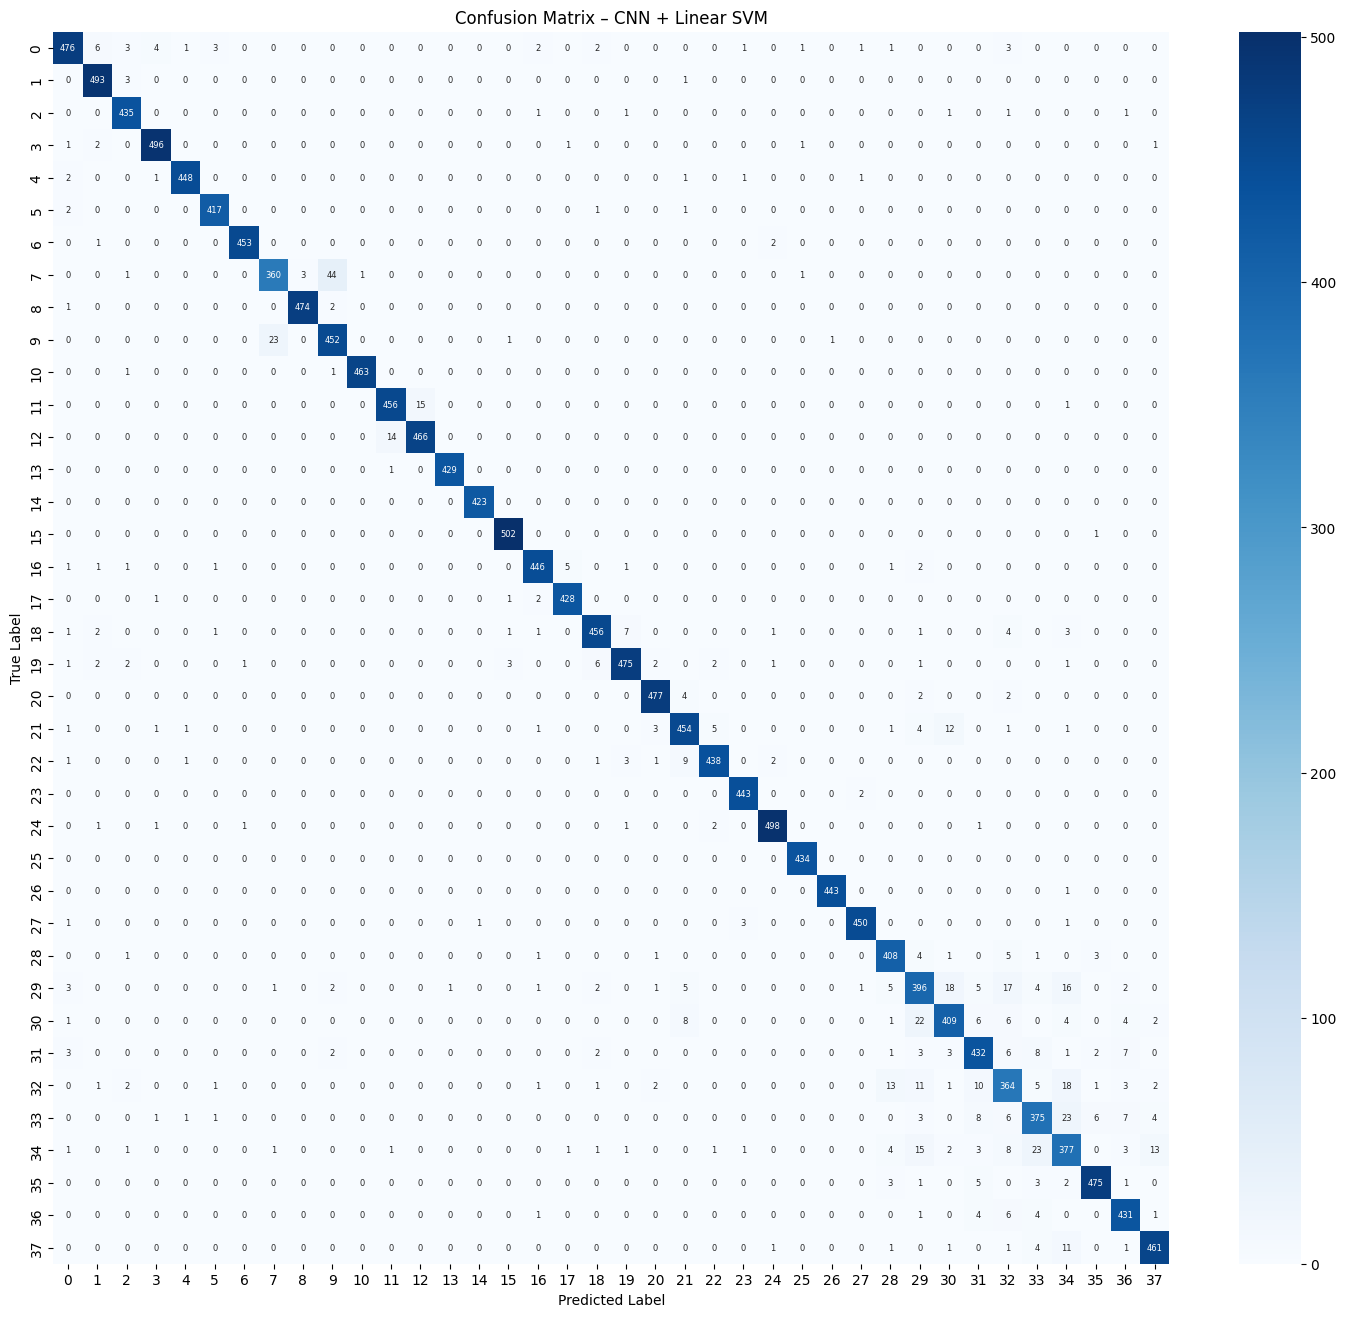

In [ ]:
cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(18, 16))
sns.heatmap(
    cm,
    cmap="Blues",
    annot=True,
    fmt="d",
    annot_kws={"size": 6},  # smaller text
    cbar=True
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix – CNN + Linear SVM")
plt.show()

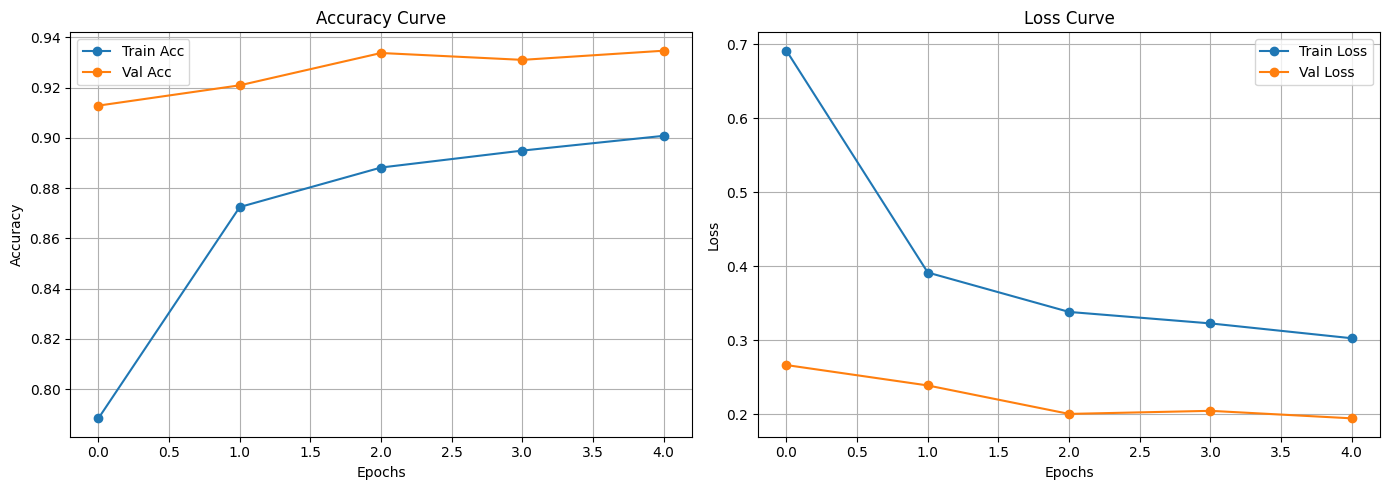

In [ ]:
plt.figure(figsize=(14, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc', marker='o')
plt.plot(history.history['val_accuracy'], label='Val Acc', marker='o')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve')
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Val Loss', marker='o')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()